# Distance Bias and Composite Motif Detection

This tutorial covers detecting and analyzing fixed-distance binding patterns:
- Detecting patterns with fixed-distance binding bias using {func}`~tfmindi.tl.detect_distance_bias`
- Visualizing distance bias with profile and heatmap plots
- Extending seqlets to capture composite motifs using {func}`~tfmindi.tl.extend_biased_seqlets`
- Re-clustering extended seqlets to identify dimers and multimers

In [1]:
import tfmindi as tm

%matplotlib inline

DATA_DIR = "../../../../data/tfmindi/"  # change to your project's data directory

DATA_DIR = "/data/groups/vib.ai/stein.aerts/lmahieu/data/tfmindi/"

In [21]:
# Load clustered data from previous tutorial
adata = tm.load_h5ad(DATA_DIR + "seqlets_clustered.h5ad")

## What is distance bias?

Distance bias occurs when transcription factor binding sites show a preference to occur at fixed distances from each other. 
For example, the SOX10-TF has a commonly occuring dimer motif that binds cooperatively, yet, seqlet calling will most likely have detected this as two separate seqlets.   

TF-MInDi can detect these patterns by analyzing contribution score profiles around identified binding sites and finding consistent peaks at fixed distances.

## Creating Patterns

First, we need to create consensus patterns for each cluster as before using {func}`~tfmindi.tl.create_patterns`.  
For distance bias detection, we recommend using the `"kmer"` method, which provides more precise pattern locations without extending beyond the actual seqlet boundaries compared to tomtom.  
Also, it's important here to not subsample when creating the pattern, since only the seqlets that were used in creating a {class}`~tfmindi.Pattern` object will be considered for detecting distance bias.  

In [3]:
patterns = tm.tl.create_patterns(adata, method="kmer")

Creating patterns for 63 clusters...


## Detecting Distance Bias

Now we can detect distance bias for each pattern using {func}`~tfmindi.tl.detect_distance_bias`.  

This function:
1. Extracts contribution scores in a window around each Seqlet from a Pattern instance
2. Aligns and averages these scores across all instances per Pattern
3. Detects peaks in the averaged profile that indicate nearby binding sites

Key parameters:
- `window`: How many basepairs up/downstream to analyze  
- `height`: Peak height threshold in the z-scored profile 

The function returns a {class}`~tfmindi.BiasDetectionResult` object containing the profile, detected peaks, and methods for further analysis.

In [4]:
# Detect distance bias for all patterns
results = {k: tm.tl.detect_distance_bias(adata, pattern, window=20) for k, pattern in patterns.items()}

In [5]:
# Check which patterns show a detected distance bias
patterns_with_bias = {k: r for k, r in results.items() if r.has_bias}
print(f"Found {len(patterns_with_bias)} patterns with distance bias out of {len(results)} total patterns")

Found 2 patterns with distance bias out of 63 total patterns


## Visualizing Distance Bias

TF-MInDi provides two plotting functions to visualize distance bias patterns:
- {func}`~tfmindi.pl.distance_bias_profile`: Line plot showing averaged contribution profile
- {func}`~tfmindi.pl.distance_bias_heatmap`: Heatmap of individual instances sorted by peak position

Both plots mark the pattern location (red) and detected peaks (orange).

### Profile Plot

The profile plot shows the averaged z-scored contribution across all instances of a pattern.  
Red lines mark the pattern location, orange lines mark detected peaks indicating nearby binding sites.

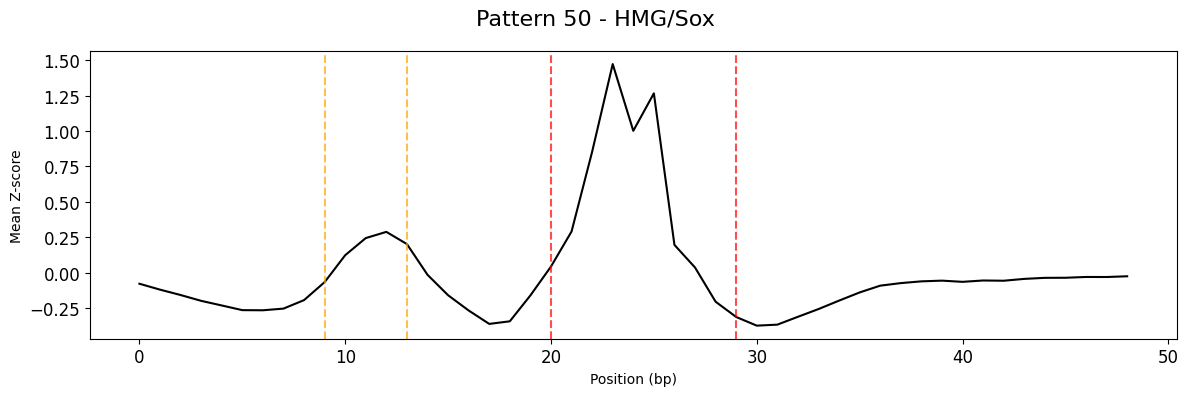

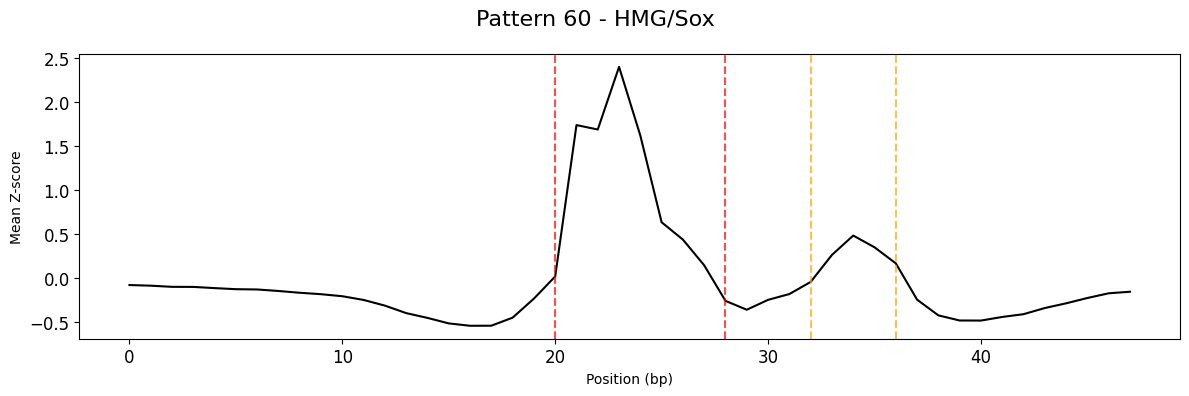

In [6]:
# Visualize both patterns with detected distance bias
for pattern_id in list(patterns_with_bias.keys()):
    result = results[pattern_id]
    tm.pl.distance_bias_profile(result, title=f"Pattern {pattern_id} - {patterns[pattern_id].dbd}", width=12, height=4)

### Heatmap Plot

The heatmap shows individual seqlet instances (rows) sorted by their maximum contribution position.  
This visualization helps identify consistent vs. variable distance bias patterns.

Use `vmin` to visualize the threshold value. In the scatterplot on the right the maximum contribution
score for each peak window is shown per seqlet instance. Seqlets above the threshold will be kept
if the value of `vmin` is used as threshold lateron.

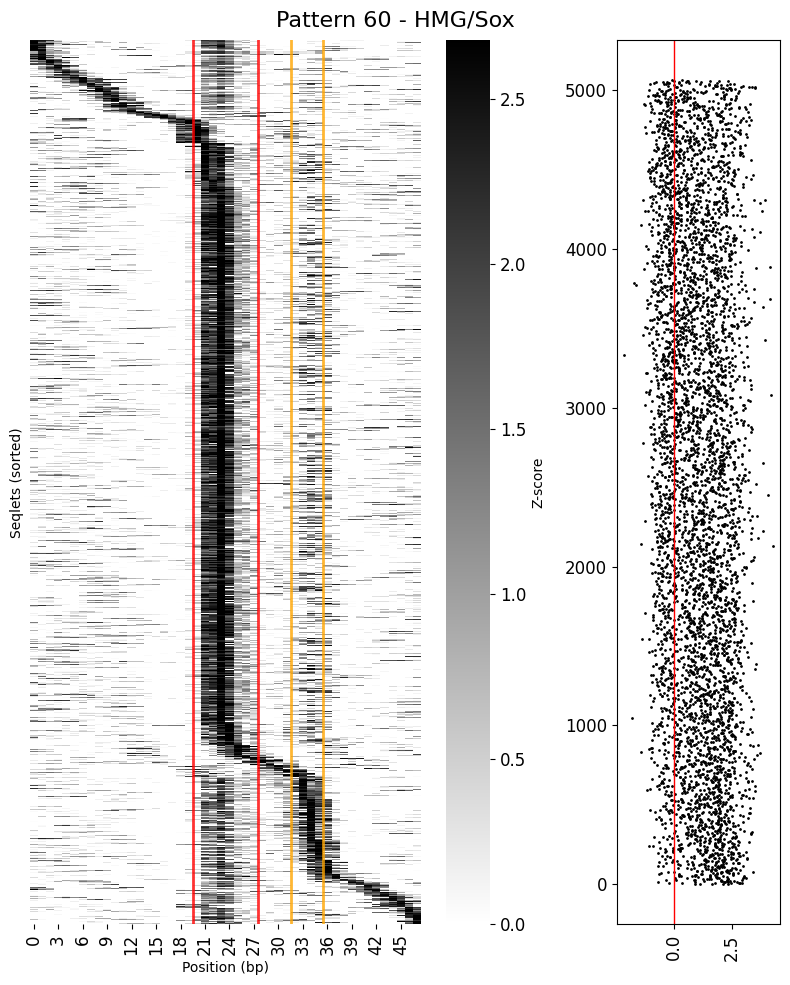

In [7]:
tm.pl.distance_bias_heatmap(result, title=f"Pattern {pattern_id} - {patterns[pattern_id].dbd}", x_label_rotation=90, vmin = 0)

## Inspecting the biased pattern motifs

When plotting the individual pattern logo's of these two patterns that have a detected bias (one upstream, one downstream), it becomes clear that these two separate patterns should have been one combined "SOX10-dimer" pattern.  
We will fix that by extending the original seqlets and recalculating the motif similarity in a next step.  

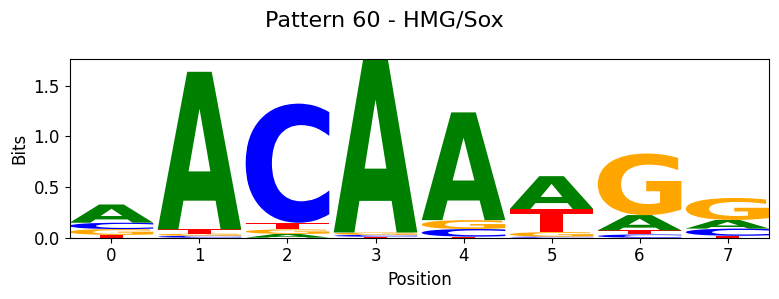

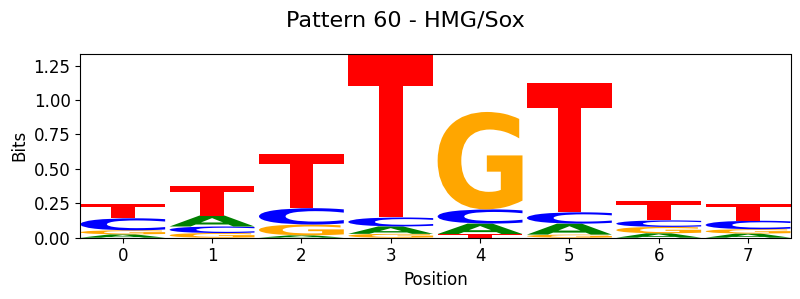

In [8]:
tm.pl.pattern_logo(
    patterns["60"],
    title=f"Pattern {pattern_id} - {patterns[pattern_id].dbd}",
    ic_threshold=0.2,
    min_nucleotides=4,
)
tm.pl.pattern_logo(
    patterns["50"],
    title=f"Pattern {pattern_id} - {patterns[pattern_id].dbd}",
    ic_threshold=0.2,
    min_nucleotides=4,
)

## Extending Seqlets to Capture Composite Motifs

Once we've identified patterns with distance bias, we can extend the seqlets to capture the full composite motif using {func}`~tfmindi.tl.extend_biased_seqlets`.

Key parameters:
- `threshold`: Z-score threshold for identifying seqlets with distance bias (default: None).
   By default no thresholding is performed. Please addapt your threshold using the {func}~`tm.pl.distance_bias_heatmap`.
   Often it is fine to not perform any thresholding, in this case all seqlet instances of the cluster will be extended,
   but please do make sure whether this makes sense for your data!
- `extra_flanks`: Additional basepairs to add beyond detected peaks (default: 7bp)
- `overlap_fraction_new/old`: Overlap thresholds for removing redundant seqlets (default: 0.7)

This function will only return the seqlets that were modified.
Furthermore, it modifies `adata` in place marking seqlets that now overlap with the extended
seqlets with `to_remove`.

In [51]:
m_adata = adata.copy()

In [ ]:
# Extend seqlets for patterns showing distance bias
results_with_bias = [r for r in results.values() if r.has_bias]

modified_seqlets_df, modified_seqlet_matrices = tm.tl.extend_biased_seqlets(
    m_adata, results_with_bias, extra_flanks=3
)

Processing seqlets: 100%|██████████| 25805/25805 [00:00<00:00, 47653.98it/s]


In [49]:
m_adata.obs

,example_idx,start,end,attribution,p-value,seqlet_matrix,seqlet_oh,example_oh_idx,example_contrib_idx,cell_type,leiden,mean_contrib,seqlet_dbd,cluster_dbd,to_remove
0,18770,1052,1065,22.867273,2.963802e-15,"[[-0.38142416, -0.21325767, 0.56363165, -0.447...","[[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0,...",0,0,Oligo,50,0.218424,HMG/Sox,HMG/Sox,True
1,19895,1103,1134,42.865262,2.971223e-15,"[[0.9126998, 0.572017, 0.33544934, 0.30004725,...","[[1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1,1,Oligo,1,0.208666,Rel,C2H2 ZF,False
2,19813,1045,1059,13.644972,4.303625e-15,"[[0.18059267, -0.007956118, -0.34745765, -0.09...","[[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0,...",2,2,Oligo,60,0.231959,HMG/Sox,HMG/Sox,True
3,19194,940,971,36.462756,5.105837e-15,"[[-0.29348123, -0.21793304, 0.4445631, -0.3771...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",3,3,Oligo,50,0.145689,HMG/Sox,HMG/Sox,True
4,12845,1107,1138,29.977118,4.511000e-13,"[[0.069043405, 0.11196814, -0.0023674, 0.97946...","[[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",4,4,SstChodl,54,0.146485,bHLH,bHLH,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
679648,3,1053,1072,0.826193,4.956198e-02,"[[-0.1998657, 0.318198, -0.06227325, -0.315696...","[[1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0,...",23940,23940,Astro,25,0.317774,TBP,HMG/Sox,False
679649,14727,1093,1104,-0.201342,4.956198e-02,"[[-0.11341425, 0.34977773, -0.19301267, 0.1464...","[[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0,...",13348,13348,Sst,10,0.218243,HMG/Sox,C2H2 ZF,False
679650,31416,1177,1188,0.385177,4.956198e-02,"[[0.538569, -0.15812883, 0.083762005, -0.40281...","[[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",24993,24993,L5_6NP,28,0.319126,Nuclear receptor,C2H2 ZF,False
679651,37997,820,831,0.365730,4.956198e-02,"[[-0.061536327, 0.04229093, 0.11652553, 0.2593...","[[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0,...",15619,15619,L5IT,47,0.238448,E2F,E2F,False


## Clustering of modified seqlets.

Now we can create a new AnnData object with the extended seqlets.

In [ ]:
# Calculate motif similarity for extended seqlets
sim_matrix_extended = tm.pp.calculate_motif_similarity(
    modified_seqlet_matrices,
    adata.var["motif_ppm"].to_dict(),
    chunk_size=50000,
    n_nearest=100,
)

In [54]:
# Create new AnnData with extended seqlets
adata_extended = tm.pp.create_seqlet_adata(
    sim_matrix_extended,
    modified_seqlets_df,
    seqlet_matrices=modified_seqlet_matrices,
    oh_sequences=adata.uns["unique_examples"]["oh"],
    contrib_scores=adata.uns["unique_examples"]["contrib"],
    motif_collection=adata.var["motif_ppm"].to_dict(),
    motif_annotations=adata.var[
        ["Direct_annot", "Motif_similarity_annot", "Orthology_annot", "Motif_similarity_and_Orthology_annot"]
    ],
    motif_to_dbd=adata.var["dbd"].to_dict(),
)

In [55]:
# Cluster the extended seqlets
tm.tl.cluster_seqlets(adata_extended, resolution=0.8)

Using CPU backend for clustering operations...
Computing PCA...
Computing neighborhood graph...


/data/groups/vib.ai/stein.aerts/sdewin/PhD/python_modules/TF-MInDi/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Computing t-SNE embedding...
Performing Leiden clustering with resolution 0.8...
Clustering complete. Found 18 clusters.
DBD annotation coverage: 25805/25805 seqlets


## Visualizing Extended Patterns

Let's create patterns from the extended seqlets and visualize them to see the captured composite motifs.

In [56]:
adata_extended.obs["cluster_dbd"].value_counts()

cluster_dbd
HMG/Sox        22398
bZIP            2482
bHLH             296
Homeodomain      261
SMAD             256
MADS box         112
Name: count, dtype: int64

In [57]:
# Create patterns from extended seqlets
patterns_extended = tm.tl.create_patterns(adata_extended, method="kmer")

Creating patterns for 18 clusters...


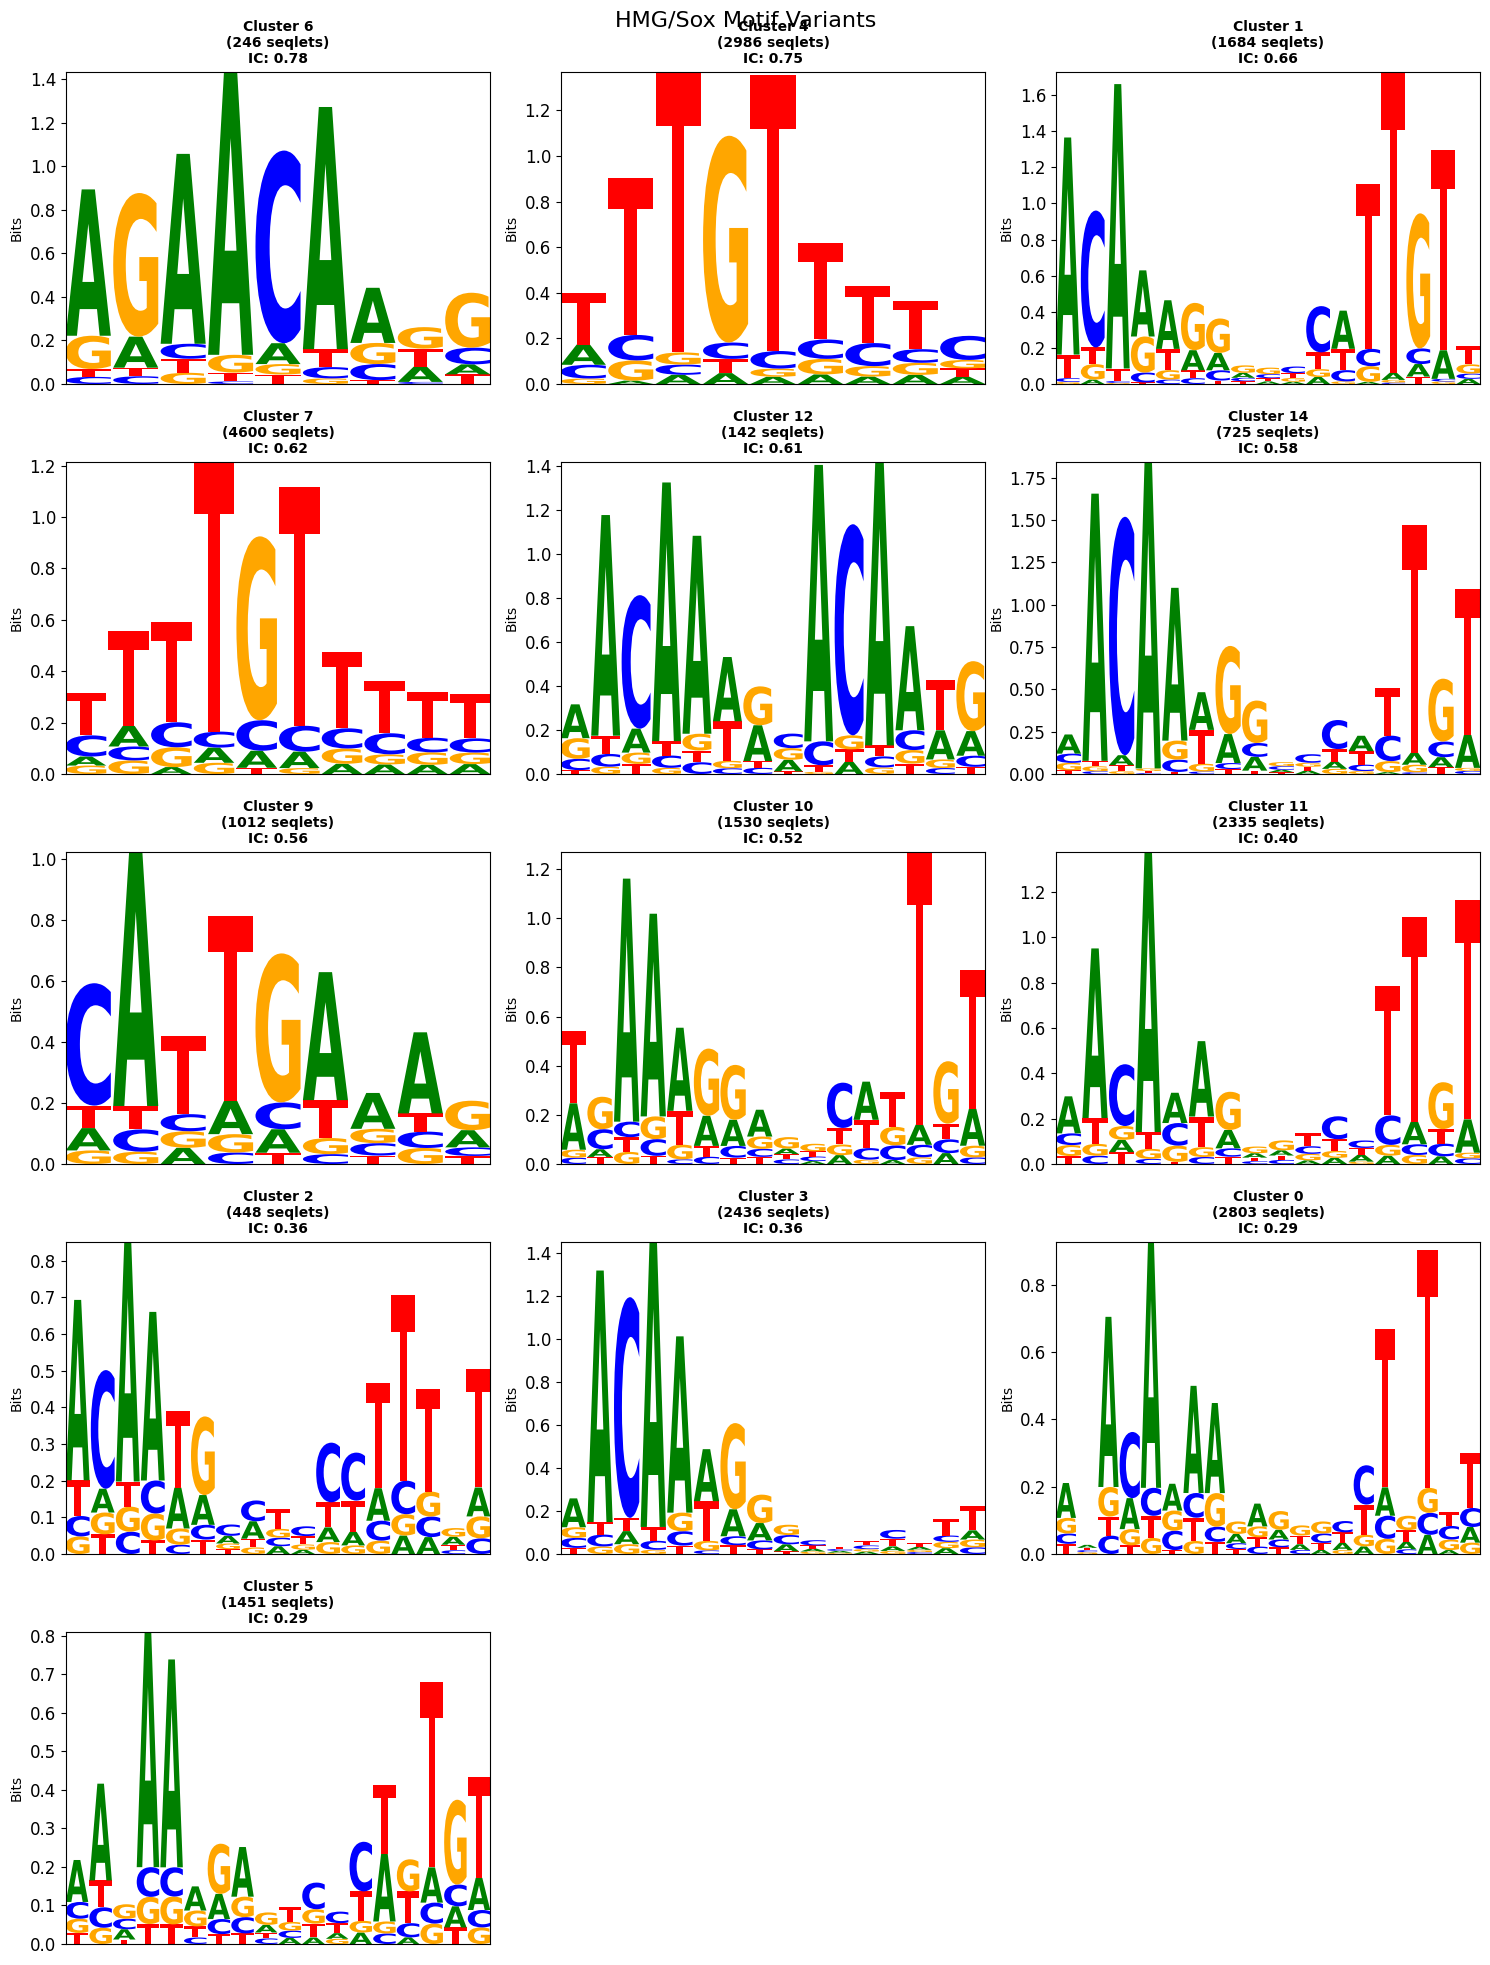

In [ ]:
tm.pl.dbd_cluster_logos(
    patterns_extended,
    dbd_name="HMG/Sox",
    ic_threshold=0.2,  # nucleotides in pattern below this will be trimmed
    min_nucleotides=4,  # ignore trimmed patterns less than 4 nucleotides (heterogeneous clusters)
    ncols=3,
    width=15,
    height=20,
)

From this it is clear that there are now many more SOX dimer motifs.

Let's change those annotations.

In [65]:
sox_dimer_clusters = [
    "1", "12", "14", "10", "11", "2", "3", "0", "5"
]

In [66]:
adata_extended.obs["cluster_dbd"] = ["sox dimer" if c in sox_dimer_clusters else dbd for dbd, c in zip(adata_extended.obs["cluster_dbd"], adata_extended.obs["leiden"], strict=True)]

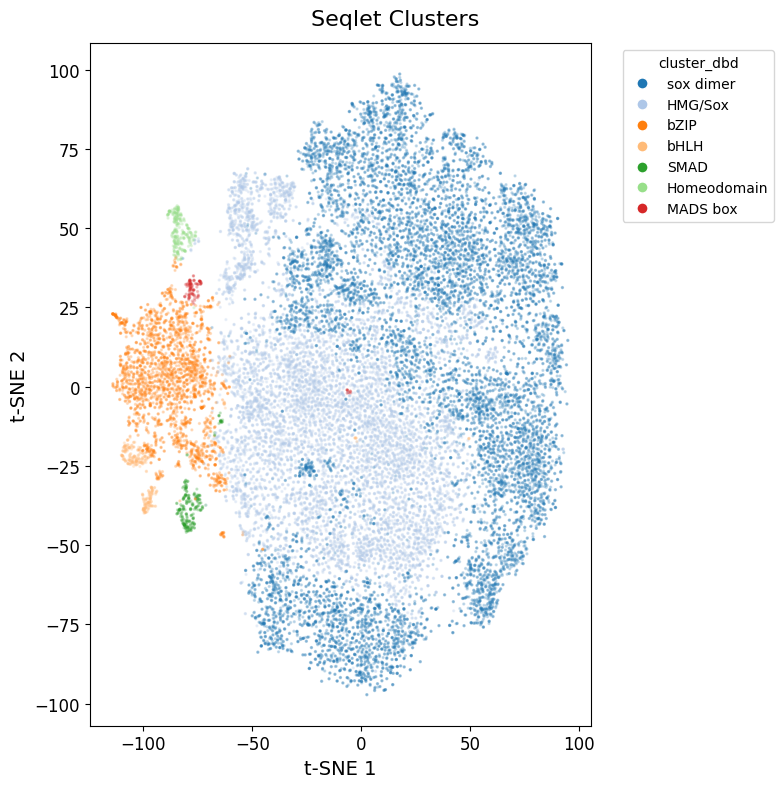

In [67]:
tm.pl.tsne(adata_extended, color_by="cluster_dbd")

After reclustering are there any new dimers found?

In [68]:
# Detect distance bias for all patterns
results = {
    k: tm.tl.detect_distance_bias(adata_extended, pattern, window=20) for k, pattern in patterns_extended.items()
}

In [69]:
# Check which patterns show a detected distance bias
patterns_with_bias_extended = {k: r for k, r in results.items() if r.has_bias}
print(f"Found {len(patterns_with_bias_extended)} patterns with distance bias out of {len(results)} total patterns")

Found 4 patterns with distance bias out of 18 total patterns


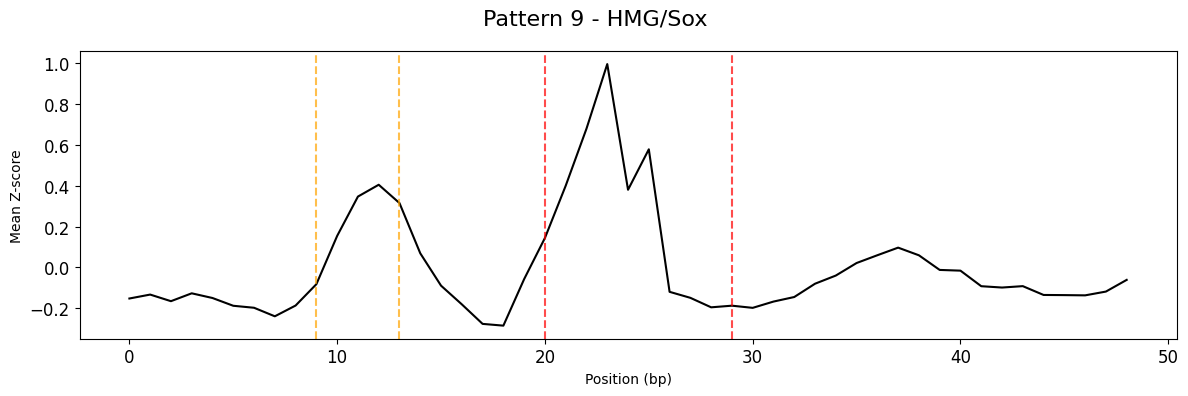

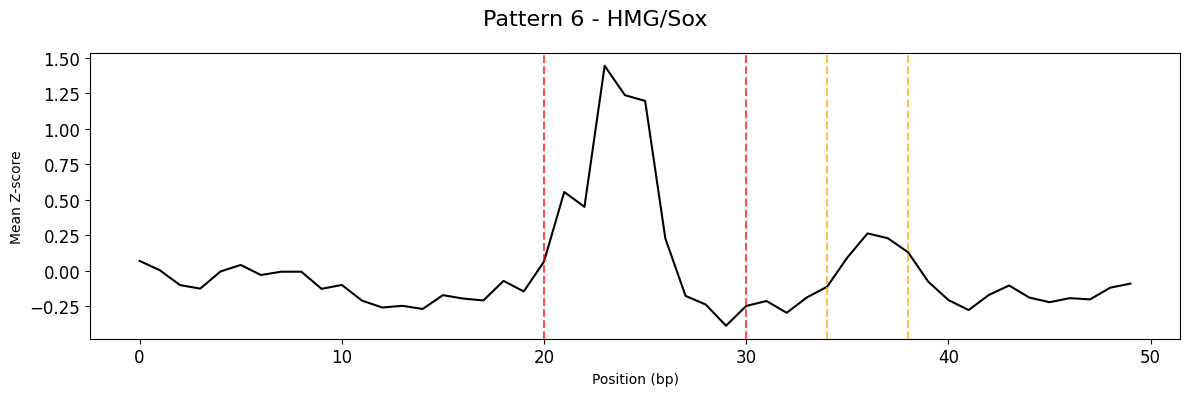

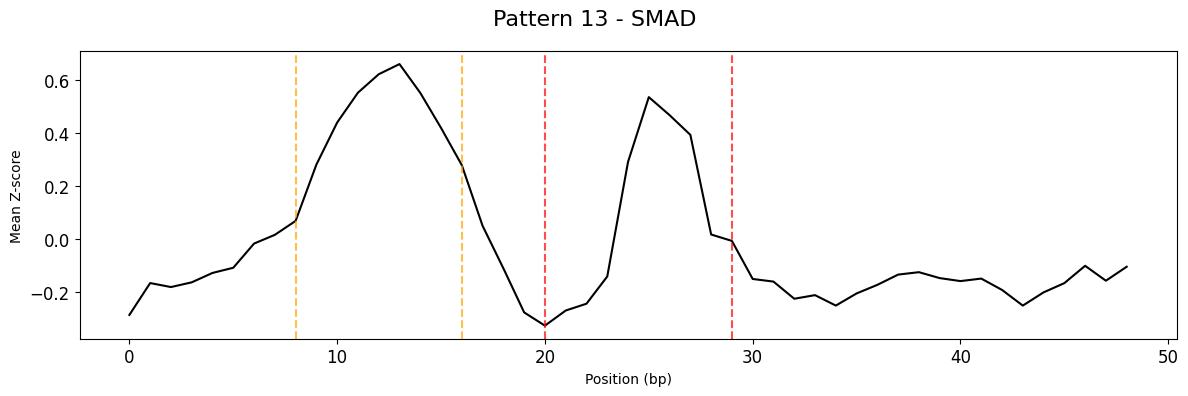

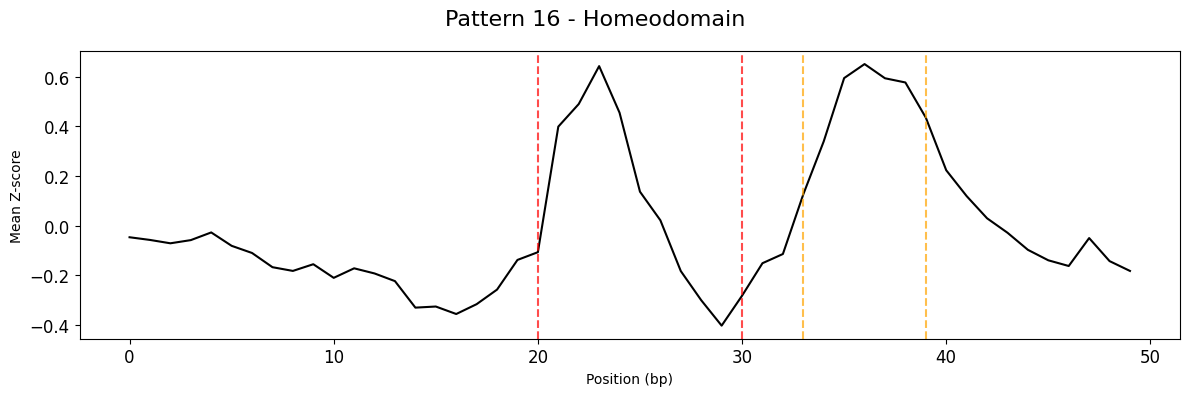

In [70]:
# Visualize both patterns with detected distance bias
for pattern_id in list(patterns_with_bias_extended.keys()):
    result = results[pattern_id]
    tm.pl.distance_bias_profile(
        result, title=f"Pattern {pattern_id} - {patterns_extended[pattern_id].dbd}", width=12, height=4
    )

Yes, so in theory we can repeat the analysis to get even more dimers.

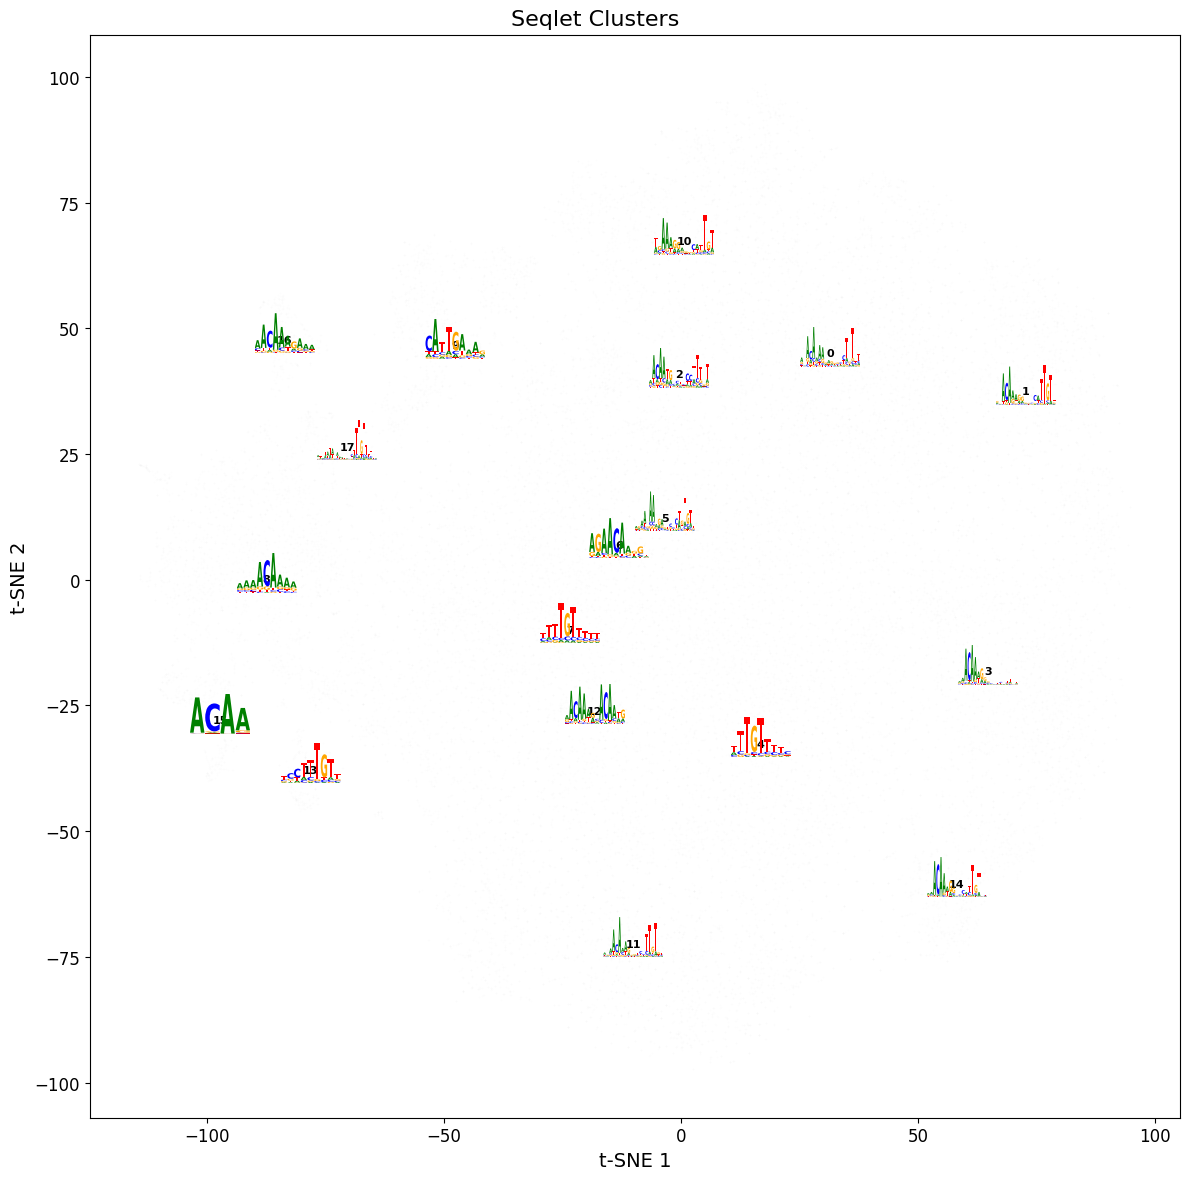

In [59]:
# Visualize extended patterns on t-SNE
tm.pl.tsne_logos(
    adata_extended,
    patterns_extended,
    gray_background=True,
    min_nucleotides=4,
    width=12,
    height=12,
    s=0.3,
    alpha=0.01,
    logo_height=0.4,
    logo_width=0.6,
    ic_threshold=0.1,
    min_seqlets=10,
)

## Create combined anndata containing all original seqlets and newly found dimers.

Now we will merge the anndata containing dimers with the original one to get
one combined object with all seqlets.

From the original object we will also remove the seqlets that overlap with
the new dimer object.

For this purpose we will use the {func}~`tm.concat` with `idx_match` set to True
to indicate that we have shared regions across our andatas.

In [ ]:
n_removed = m_adata.shape[0] - m_adata[~m_adata.obs["to_remove"]].shape[0]
print(f"{n_removed} overlapping seqlets will be removed.")

36928 overlapping seqlets will be removed.


In [91]:
# make indeces compatible with original adata
# how can we do this in a clean way?
adata_extended.obs["example_oh_idx"] = adata_extended.obs["example_idx"]
adata_extended.obs["example_contrib_idx"] = adata_extended.obs["example_idx"]

# copy over uns from original adata --> concat function with idx_match = True expects that all uns["unique_examples"] are the same

adata_extended.uns["unique_examples"] = m_adata.uns["unique_examples"]

In [92]:
adata_extended.obs

,example_idx,start,end,to_remove,seqlet_matrix,seqlet_oh,example_oh_idx,example_contrib_idx,leiden,mean_contrib,seqlet_dbd,cluster_dbd
0,0,1039,1065,False,"[[-0.049527206, 0.102994844, 0.018646317, 0.30...","[[0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0,...",0,0,0,0.201165,HMG/Sox,sox dimer
1,3,927,953,False,"[[-0.11870343, 0.075451344, 0.082450494, 0.203...","[[1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0,...",3,3,0,0.184598,HMG/Sox,sox dimer
2,6,1028,1054,False,"[[0.051433004, -0.019439321, 0.21764928, 0.446...","[[0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0,...",6,6,4,0.193598,HMG/Sox,HMG/Sox
3,9,1049,1075,False,"[[0.08525264, 0.42246264, 0.27719012, -0.30972...","[[1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",9,9,4,0.227583,HMG/Sox,HMG/Sox
4,38,927,953,False,"[[-0.13077785, 0.11250165, 0.11582164, 0.28549...","[[1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0,...",38,38,0,0.212135,HMG/Sox,sox dimer
...,...,...,...,...,...,...,...,...,...,...,...,...
25800,2424,1047,1069,False,"[[-0.1763143, -0.16293056, -0.37010723, 0.0520...","[[1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0,...",2424,2424,3,0.175411,HMG/Sox,sox dimer
25801,22369,1933,1955,False,"[[0.098109595, 0.2392444, 0.63143104, -0.55678...","[[0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0,...",22369,22369,1,0.237694,HMG/Sox,sox dimer
25802,9239,984,1006,False,"[[0.31536388, -0.10066209, 0.022054456, -0.010...","[[1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0,...",9239,9239,8,0.206150,Nuclear receptor,bZIP
25803,9151,903,925,False,"[[0.03811226, -0.029408624, 0.30493113, 0.8063...","[[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0,...",9151,9151,3,0.237699,HMG/Sox,sox dimer


In [115]:
m_adata.var.dtypes

motif_ppm                                 object
Direct_annot                            category
Motif_similarity_annot                  category
Orthology_annot                         category
Motif_similarity_and_Orthology_annot    category
dbd                                     category
dtype: object

In [ ]:
adata_extended.var.dtypes

motif_ppm                               object
Direct_annot                            object
Motif_similarity_annot                  object
Orthology_annot                         object
Motif_similarity_and_Orthology_annot    object
dbd                                     object
dtype: object

In [124]:
import pandas as pd

pd.testing.assert_frame_equal(m_adata.var.astype("object"), adata_extended.var)

In [125]:
combined_adata = tm.concat(
    {
        "orig": m_adata[~m_adata.obs["to_remove"]],
        "dimer": adata_extended
    },
    idx_match=True,
    merge="first" # Using first, because "same" is very strict. Only the dtypes differ between both dataframes ...
)

In [127]:
tm.tl.cluster_seqlets(combined_adata)

Using CPU backend for clustering operations...
Reusing existing PCA...
Computing neighborhood graph...
Reusing existing t-SNE embedding...
Performing Leiden clustering with resolution 3.0...
Clustering complete. Found 65 clusters.
DBD annotation coverage: 668530/668530 seqlets


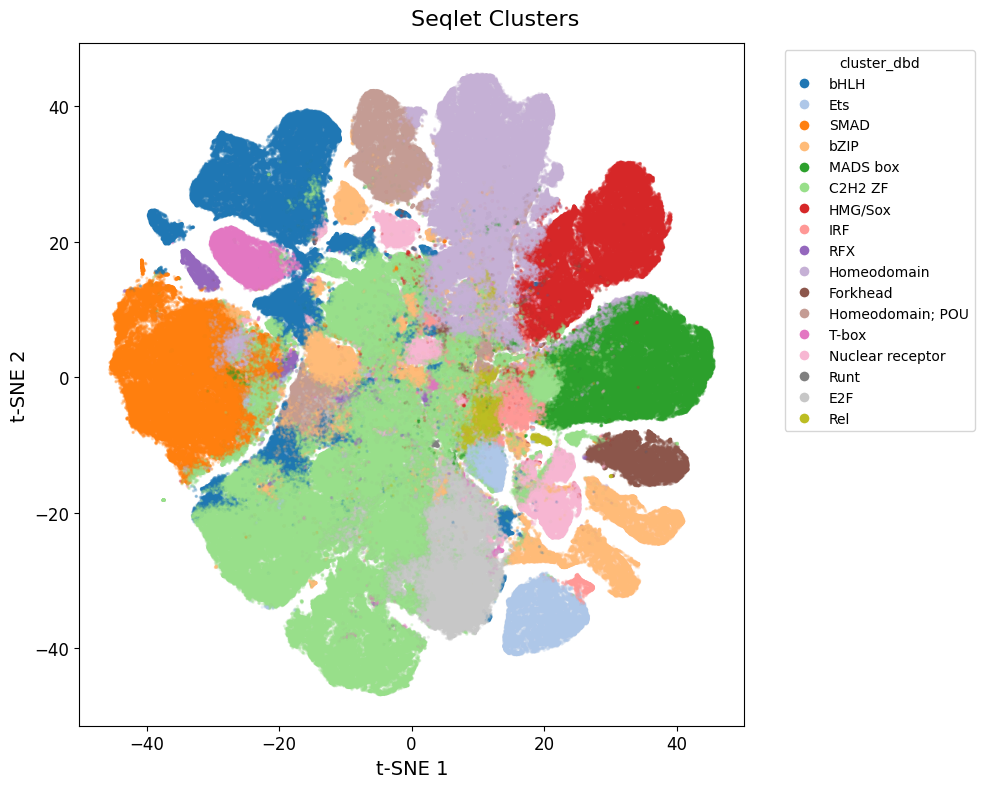

In [133]:
tm.pl.tsne(combined_adata, color_by="cluster_dbd", width = 10, height = 8)

In [135]:
# Create patterns from extended seqlets
patterns_combined = tm.tl.create_patterns(combined_adata, method="kmer", max_n=100)

Creating patterns for 65 clusters...


In [ ]:
tm.pl.dbd_cluster_logos(
    patterns_combined,
    dbd_name="HMG/Sox",
    ic_threshold=0.2,  # nucleotides in pattern below this will be trimmed
    min_nucleotides=4,  # ignore trimmed patterns less than 4 nucleotides (heterogeneous clusters)
    ncols=3,
    width=15,
    height=20,
)